# Land Cover Time Series Analysis - Curuai Watershed

## Overview

This notebook performs a comprehensive analysis of Land Use and Land Cover (LULC) changes over time in the Curuai watershed study area. The analysis:

- **Consolidates** LULC data from multiple source files
- **Categorizes** land cover into Natural (Forest, Savanna, Wetland, Grassland) and Anthropic (Pasture, Urban, Crops) classes
- **Aggregates** data by year, watershed, and class
- **Visualizes** temporal trends with publication-quality plots

## Output

Time series plots saved to: `datasets/Parameters Time series/Results/Area/LULC_time_series.jpg`

Each plot represents area changes (km²) for a specific watershed and land cover class combination.

<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/7.land_cover_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Required Libraries

This notebook analyzes Land Use and Land Cover (LULC) time series data from the Curuai study area.

**Workflow:**
1. Load and organize LULC data from CSV files
2. Classify land cover types into Natural and Anthropic categories
3. Generate time series visualizations for each watershed and class

**Key Dependencies:**
- `pandas`: Data manipulation and aggregation
- `matplotlib`: Visualization
- `glob`: File path searching
- `os`: Directory operations
- `math`: Mathematical calculations for grid layout

In [162]:
from glob import glob
import matplotlib.pyplot as plt
import os
import math
import pandas as pd

In [ ]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.labelsize'] = 14  # Axis label font size
plt.rcParams['axes.titlesize'] = 14  # Plot title font size
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 14  # Legend font size

In [163]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Define data directories
data_directory = r'C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Results\LULC'
exp_directory = r'C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Results'

# data_directory: Location of raw LULC CSV files
# exp_directory: Base directory for saving processed results and plots

## Data Organization Function

The `get_df_from_paths()` function processes raw LULC data:

**Steps:**
1. Reads multiple CSV files from a directory
2. Removes unnecessary columns (`.geo`, `system:index`)
3. Standardizes land cover class names into two categories:
   - **Natural**: Forest, Savanna, Wetland, Grassland
   - **Anthropic**: Pasture, Urban, Non-vegetated, Crops
4. Aggregates data by year, class, and watershed
5. Filters for only Natural and Anthropic classes
6. Returns a clean DataFrame ready for visualization

**Output:** DataFrame with columns: year, class_name, watershed, area_km2

In [165]:
def get_df_from_paths (path_list):
    df_list = []

    for path in path_list:
        try:
            x = pd.read_csv(path)
            df_list.append(x.drop(columns=['.geo','system:index']))
        except:
            print(f'{path} file not error!')
            print('Moving to next path')
            continue
    
    data = pd.concat(df_list)


    def reset_df (df):
        def set_classes(row):
            if row in ['Pasture','Urban Infrastructure', 'Other Non Vegetated Area','Mosaic of Crops']:
                return 'Anthropic'
            elif row in[ 'Forest Formation', 'Savanna Formation', 'Wetland','Grassland']:
                return 'Natural'
            else:
                return row

        df['class_name'] = df['class_name'].apply(set_classes) 
        df = df.loc[df['class_name'].isin(['Natural','Anthropic'])].copy()
        df = df.groupby(by=['year','class_name','watershed']).sum().drop(columns='class')
        
        

        return df
    df = reset_df(data).reset_index()
    df['watershed'] = df['watershed'].apply(lambda name: name[9:])
    return df
      

## Time Series Visualization Function

The `prepare_time_series_plot()` function creates publication-quality time series plots with two distinct modes:

**Grid Mode** (Area Data):
- Creates a grid layout with 4 rows and N columns
- Each subplot represents a unique watershed-class combination
- Shows area trends over time with connected points
- Gray dashed background line shows overall trend
- Automatic legend and axis labels

**Single Time Series Mode** (Other Variables):
- For TSS, precipitation, discharge, wind data
- Single plot with all data points
- Points colored by water period/season
- Automatically selects output directory based on variable type

**Features:**
- Customizable color palettes
- Grid overlay for readability  
- Automatic directory creation
- 300 DPI output for publication quality
- Handles empty data gracefully

### Function Usage Example

```python
# For area data (creates grid layout)
prepare_time_series_plot(dados, 'area_km2', 'LULC', save_dir=data_directory)

# For other environmental variables
prepare_time_series_plot(dados, 'TSS', 'Total Suspended Solids')
prepare_time_series_plot(dados, 'discharge', 'River Discharge')
```

### Parameters
- **df**: Input DataFrame with time series data
- **var**: Column name to plot (e.g., 'area_km2', 'TSS', 'discharge')
- **title**: Plot title and output filename
- **color_palette**: Optional list of colors (default: ['#d62728', '#2ca02c'])
- **save_dir**: Output directory (default: current directory)

In [166]:
def prepare_time_series_plot(df, var, title, color_palette=None, save_dir=None):
    """
    Refined time series plotter for environmental and spatial data.
    """
    if df.empty:
        print(f"Warning: DataFrame for {var} is empty. Skipping plot.")
        return

    # Modern path handling: Use save_dir if provided, else default to current
    base_dir = save_dir if save_dir else "."
    
    # Logic for Grid Plotting (Area-specific)
    if "area" in var:
        watersheds = sorted(df['watershed'].unique())
        classes = sorted(df['class_name'].unique())
        
        num_plots = len(watersheds) * len(classes)
        num_rows = 4
        num_cols = math.ceil(num_plots / num_rows)
        
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(16 * num_cols, 6 * num_rows))
        axes = axes.flatten()
        
        df = df.sort_values(by='year')
        palette = color_palette or [ '#d62728','#2ca02c']
        
        plot_idx = 0
        for watershed in watersheds:
            for classe in classes:
                df_sub = df[(df['watershed'] == watershed) & (df['class_name'] == classe)]
                
                if not df_sub.empty:
                    color = palette[classes.index(classe) % len(palette)]
                    ax = axes[plot_idx]
                    ax.plot(df_sub['year'], df_sub[var], alpha=0.3, color='gray', 
                linestyle='--', linewidth=1, zorder=1)
                    
                    ax.plot(df_sub['year'], df_sub[var], marker='o', 
                            markersize=8, alpha=0.7, color=color, 
                            linestyle='none', label=classe)
                    
                    ax.set_xlabel('Year')
                    ax.set_ylabel("Area (km$^2$)")
                    ax.set_title(f"{watershed}", fontsize=10)
                    ax.legend(loc='best', fontsize='small')
                    
                
                plot_idx += 1
        
        # Cleanup unused axes
        for i in range(plot_idx, len(axes)):
            axes[i].set_visible(False)
            
        final_dir = os.path.join(base_dir, "Area")

    # Logic for Single Continuous Time Series
    else:
        fig, ax = plt.subplots(figsize=(16, 6))
        df = df.sort_values(by='time_start')

        # Background trend line
        ax.plot(df['time_start'], df[var], alpha=0.3, color='gray', 
                linestyle='--', linewidth=1, zorder=1)
        
        water_periods = sorted(df['water_period'].unique())
        palette = color_palette or ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        
        for i, period in enumerate(water_periods):
            subset = df[df['water_period'] == period]
            ax.scatter(subset['time_start'], subset[var], 
                       color=palette[i % len(palette)], label=period, 
                       alpha=0.6, edgecolors='w', s=60, zorder=2)

        # Dynamic Labeling
        labels = {
            "TSS": ("TSS\n(mg/L)", "TSS"),
            "chirps": ("Accumulated Precipitation\n(mm/Period)", "Precipitation"),
            "discharge": ("Mean Discharge\n(m$^3$/s)", "Discharge"),
            "wind": ("Mean Wind Speed\n(m/s)", "Wind")
        }
        
        # Default fallback
        ylabel, sub_folder = ("Value", "General")
        for key, (lab, folder) in labels.items():
            if key in var:
                ylabel, sub_folder = lab, folder
                break
        
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Date')
        ax.set_title(f"{title} vs Time", fontsize=14)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        final_dir = os.path.join(base_dir, sub_folder)

    # Ensure directory exists and save
    os.makedirs(final_dir, exist_ok=True)
    plt.tight_layout()
    plt.savefig(os.path.join(final_dir, f"{title}_time_series.jpg"), dpi=300)
    plt.show()
    plt.close()

## Processing and Visualizing LULC Data

This section executes the full workflow:
1. Load all CSV files from the LULC directory
2. Consolidate and clean the data using `get_df_from_paths()`
3. Inspect the processed data structure
4. Save the consolidated dataset
5. Generate time series visualization plots

In [ ]:
# Find all CSV files in the data directory
path_list = glob(os.path.join(data_directory, '*.csv'))
print(f"Found {len(path_list)} CSV files in LULC directory")

In [ ]:
# Load and process all CSV files into a single consolidated DataFrame
dados = get_df_from_paths(path_list)
print(f"Processed data shape: {dados.shape}")
print(f"Data types:\n{dados.dtypes}")
print(f"\nFirst few rows:")
dados.head()

Index(['year', 'class_name', 'watershed', 'area_km2'], dtype='object')

In [169]:
dados

,year,class_name,watershed,area_km2
0,1985,Anthropic,Local Watershed,48.897800
1,1985,Anthropic,Regional Watershed,1637.268807
2,1985,Natural,Local Watershed,1838.000682
3,1985,Natural,Regional Watershed,305485.474607
4,1986,Anthropic,Local Watershed,49.877077
...,...,...,...,...
155,2023,Natural,Regional Watershed,298928.844887
156,2024,Anthropic,Local Watershed,224.678151
157,2024,Anthropic,Regional Watershed,5247.887401
158,2024,Natural,Local Watershed,1674.648490


In [170]:
dados.to_csv(os.path.join(exp_directory,'lulc_data.csv'))

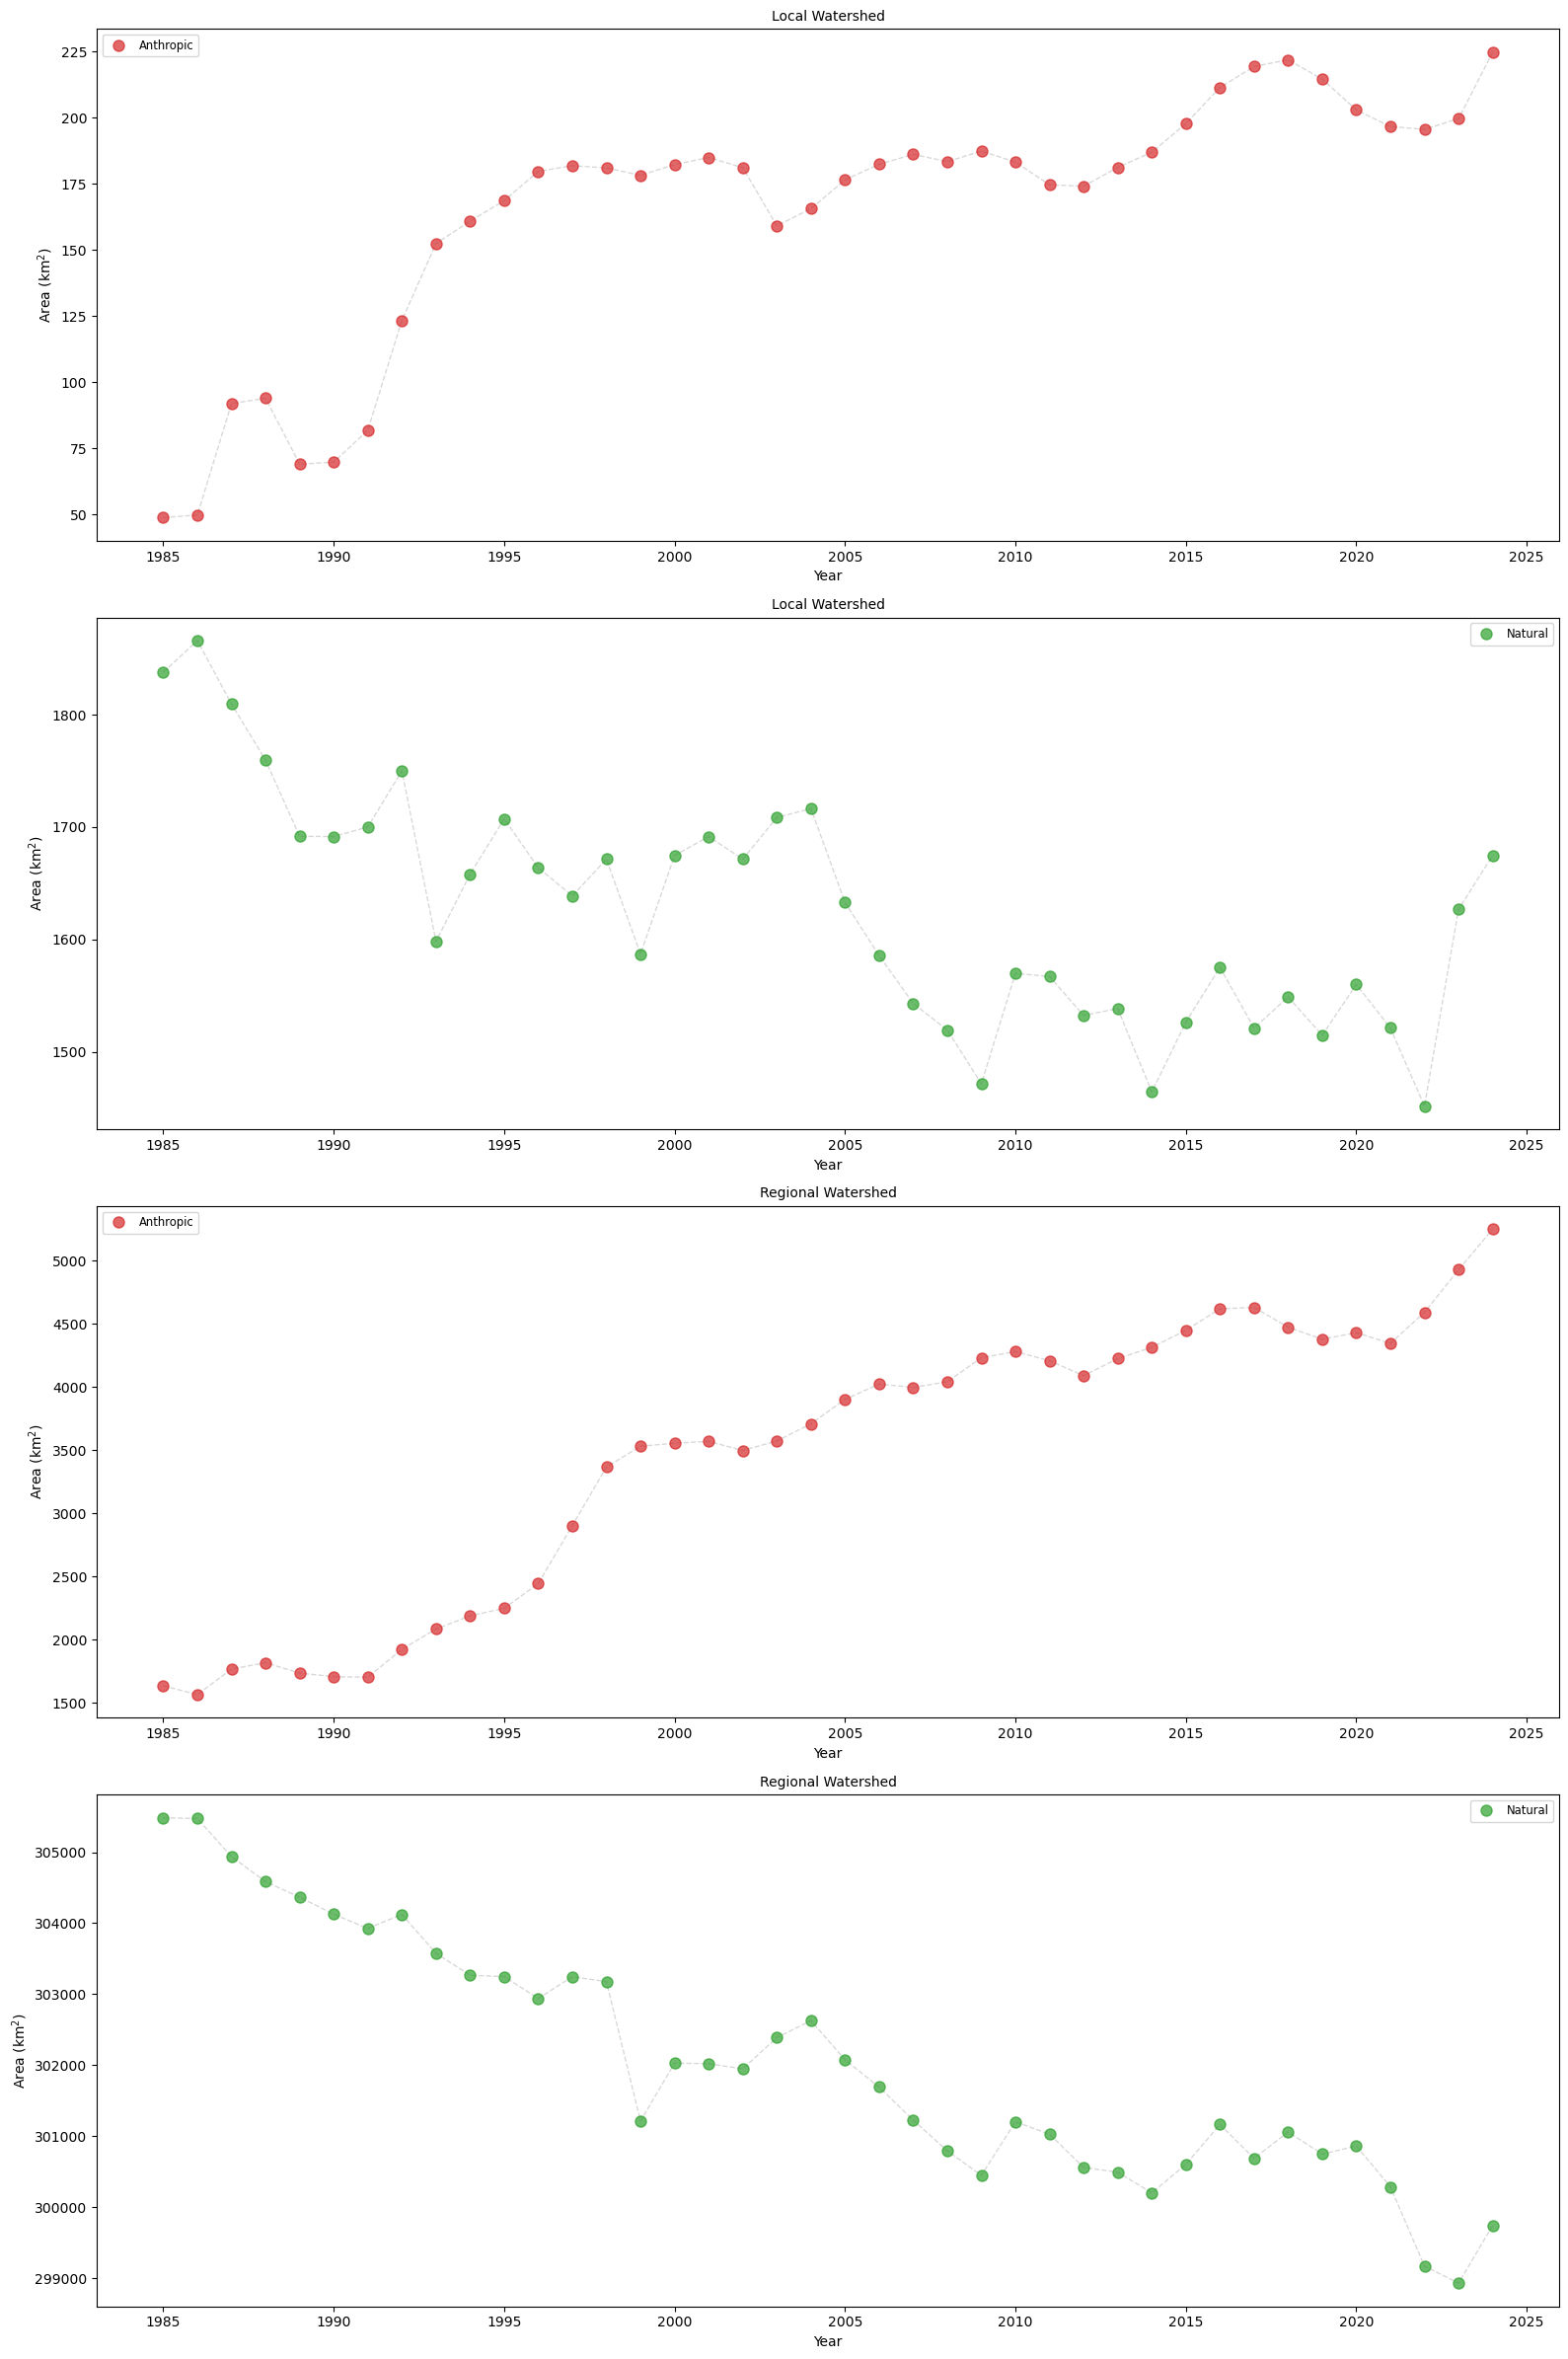

In [ ]:
# Generate time series visualizations
# Creates a grid of plots: 4 rows × N columns, one for each watershed-class combination
print("Generating time series plots for LULC area data...")
prepare_time_series_plot(dados, 'area_km2', 'LULC', save_dir=data_directory)
print("✓ Plot generation complete!")